In [18]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import json
import time
import math

import torch
import torchaudio
import jiwer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from datasets import load_dataset

from wav2vec2decoder import Wav2Vec2Decoder

## Data preparation

In [ ]:
from datasets import load_dataset

libre_data_other_test = load_dataset("librispeech_asr", 'other', split="test", streaming=True)

In [32]:
def evaluate(decoder, iter_dataset, method="greedy", ref_field="text"):
    refs, hyps = [], []
    for i, sample in enumerate(tqdm(iter_dataset, desc=method, leave=False, total=200)):
        if i == 200:
            break
        audio = torch.tensor(sample["audio"]["array"]).unsqueeze(0)
        hyp = decoder.decode(audio, method=method)
        refs.append(sample[ref_field].lower())
        hyps.append(hyp)
    wer = jiwer.wer(refs, hyps)
    cer = jiwer.cer(refs, hyps)
    return wer, cer, list(zip(refs, hyps))

## Task 1 — Greedy Decoding

In [8]:
decoder_no_lm = Wav2Vec2Decoder(lm_model_path=None, beam_width=3)

wer_greedy, cer_greedy, pairs_greedy = evaluate(decoder_no_lm, libre_data_other_test, method="greedy")
print(f"Task 1 — Greedy on LibriSpeech test-other")
print(f"  WER: {wer_greedy:.2%}  (ref ~10.4%)")
print(f"  CER: {cer_greedy:.2%}  (ref ~3.5%)")

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 80477.19it/s]
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-100h
Key                           | Status     | 
------------------------------+------------+-
wav2vec2.mask_time_emb_vector | UNEXPECTED | 
wav2vec2.masked_spec_embed    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                         

Task 1 — Greedy on LibriSpeech test-other
  WER: 11.22%  (ref ~10.4%)
  CER: 3.81%  (ref ~3.5%)


## Task 2 — Beam Search Decoding

In [9]:
wer_beam, cer_beam, pairs_beam = evaluate(decoder_no_lm, libre_data_other_test, method="beam")
print(f"Task 2 — Beam search (width=3) on LibriSpeech test-other")
print(f"  WER: {wer_beam:.2%}  (ref ~9.9%)")
print(f"  CER: {cer_beam:.2%}  (ref ~3.4%)")

Task 2 — Beam search (width=3) on LibriSpeech test-other
  WER: 11.15%  (ref ~9.9%)
  CER: 3.78%  (ref ~3.4%)


In [ ]:
# Beam width sweep
beam_widths = [1, 3, 10, 50]
beam_results = []

for bw in beam_widths:
    dec = Wav2Vec2Decoder(lm_model_path=None, beam_width=bw)
    t0 = time.time()
    wer, cer, _ = evaluate(dec, libre_data_other_test, method="beam")
    elapsed = time.time() - t0
    beam_results.append({"beam_width": bw, "WER": wer, "CER": cer, "time_s": elapsed})
    print(f"  beam_width={bw:3d} | WER={wer:.2%} | CER={cer:.2%} | time={elapsed:.1f}s")

df_beam = pd.DataFrame(beam_results)

In [19]:
df_beam

,beam_width,WER,CER,time_s
0,1,0.112442,0.038031,40.906685
1,3,0.111464,0.037837,52.258179
2,10,0.110731,0.037692,88.736125
3,50,0.110975,0.037692,334.675545


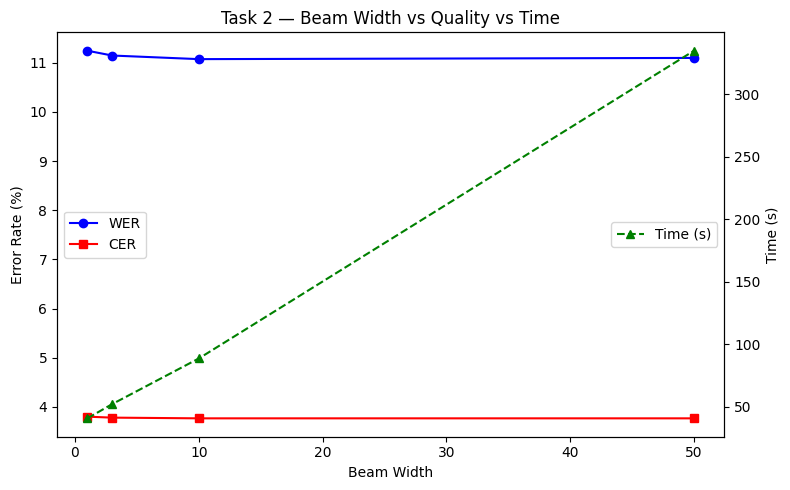

In [11]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(df_beam["beam_width"], df_beam["WER"] * 100, "o-b", label="WER")
ax1.plot(df_beam["beam_width"], df_beam["CER"] * 100, "s-r", label="CER")
ax1.set_xlabel("Beam Width")
ax1.set_ylabel("Error Rate (%)")
ax1.legend(loc="center left")

ax2 = ax1.twinx()
ax2.plot(df_beam["beam_width"], df_beam["time_s"], "^--g", label="Time (s)")
ax2.set_ylabel("Time (s)")
ax2.legend(loc="center right")

plt.title("Task 2 — Beam Width vs Quality vs Time")
plt.tight_layout()
plt.show()

### Task 2 — Summary

- Beam search provides a small but consistent improvement over greedy decoding: WER drops from 11.22% (greedy) to 11.15% (beam_width=3).
- Increasing beam width yields diminishing returns: the best WER is 11.07% at beam_width=10, but beam_width=50 (WER=11.10%) is actually slightly worse while being **8× slower** (335s vs 41s).
- The quality-vs-speed trade-off favors **beam_width=3**: it achieves nearly optimal WER with only ~30% overhead compared to greedy (beam_width=1).
- The limited improvement from wider beams suggests that the acoustic model is already highly confident in its top predictions, leaving little room for beam search to find better alternatives.

## Task 3 — Temperature Scaling (Greedy)

In [ ]:
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
temp_results = []

for T in temperatures:
    dec = Wav2Vec2Decoder(lm_model_path=None, temperature=T)
    wer, cer, _ = evaluate(dec, libre_data_other_test, method="greedy")
    temp_results.append({"temperature": T, "WER": wer, "CER": cer})
    print(f"  T={T:.1f} | WER={wer:.2%} | CER={cer:.2%}")

df_temp = pd.DataFrame(temp_results)

In [20]:
df_temp

,temperature,WER,CER
0,0.5,0.112198,0.038128
1,0.8,0.112198,0.038128
2,1.0,0.112198,0.038128
3,1.2,0.112198,0.038128
4,1.5,0.112198,0.038128
5,2.0,0.112198,0.038128


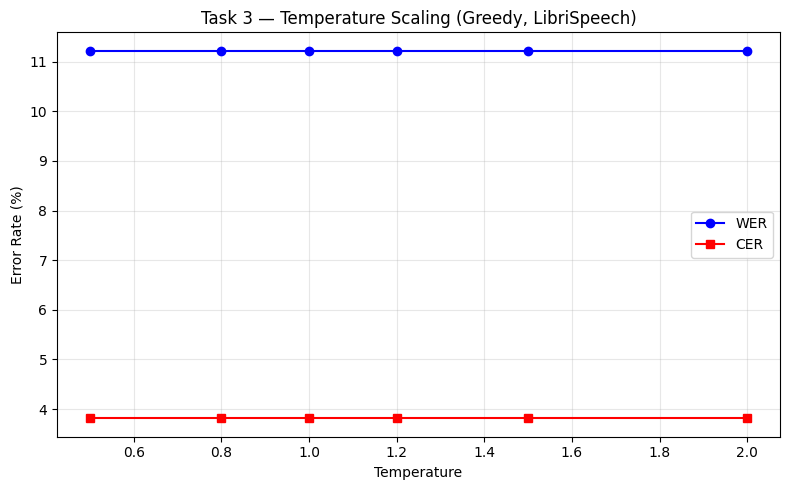

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(df_temp["temperature"], df_temp["WER"] * 100, "o-b", label="WER")
plt.plot(df_temp["temperature"], df_temp["CER"] * 100, "s-r", label="CER")
plt.xlabel("Temperature")
plt.ylabel("Error Rate (%)")
plt.title("Task 3 — Temperature Scaling (Greedy, LibriSpeech)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 3 — Summary

- Temperature scaling has **no effect** on greedy CTC decoding: WER and CER remain constant at 11.22% and 3.81% across all tested temperatures (0.5–2.0).
- This is because greedy decoding always selects the argmax token at each timestep. Scaling the logits by a temperature factor before softmax does not change the relative ordering of token probabilities — the argmax remains the same.
- Temperature scaling would only affect methods that sample from the distribution or use the probability values (e.g., beam search, nucleus sampling), not pure greedy decoding.

## Task 4 — Beam Search with LM (Shallow Fusion, 3-gram)

In [ ]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas = [0.0, 0.5, 1.0, 1.5]

sf_results = []
for alpha in alphas:
    for beta in betas:
        dec = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=3, alpha=alpha, beta=beta
        )
        wer, cer, _ = evaluate(dec, libre_data_other_test, method="beam_lm")
        sf_results.append({"alpha": alpha, "beta": beta, "WER": wer, "CER": cer})
        print(f"  alpha={alpha:.2f}, beta={beta:.1f} | WER={wer:.2%} | CER={cer:.2%}")

df_sf = pd.DataFrame(sf_results)

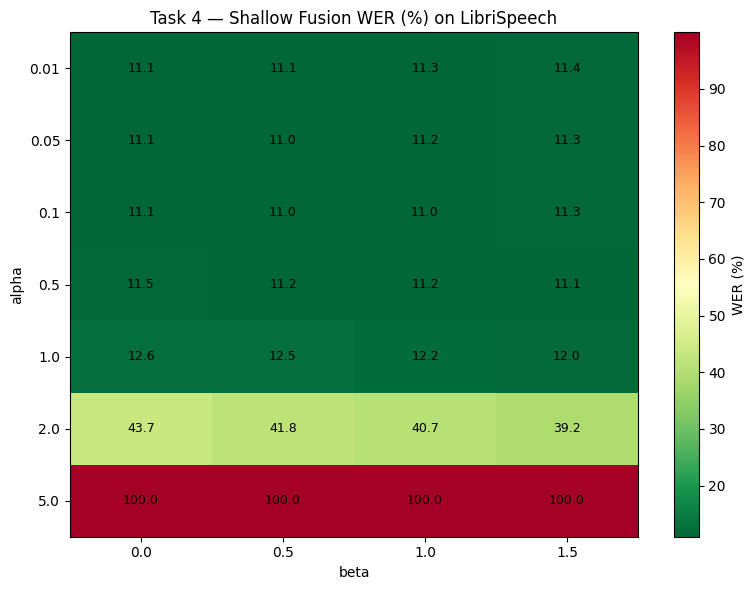


Best shallow fusion: alpha=0.1, beta=0.5 -> WER=10.98%, CER=3.75%


In [24]:
# Heatmap for shallow fusion WER
pivot_wer = df_sf.pivot(index="alpha", columns="beta", values="WER") * 100

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot_wer.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(betas)))
ax.set_xticklabels(betas)
ax.set_yticks(range(len(alphas)))
ax.set_yticklabels(alphas)
ax.set_xlabel("beta")
ax.set_ylabel("alpha")
ax.set_title("Task 4 — Shallow Fusion WER (%) on LibriSpeech")

for i in range(len(alphas)):
    for j in range(len(betas)):
        ax.text(j, i, f"{pivot_wer.values[i, j]:.1f}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, label="WER (%)")
plt.tight_layout()
plt.show()

best_sf = df_sf.loc[df_sf["WER"].idxmin()]
print(f"\nBest shallow fusion: alpha={best_sf['alpha']}, beta={best_sf['beta']} -> WER={best_sf['WER']:.2%}, CER={best_sf['CER']:.2%}")

### Task 4 — Summary

- The best shallow fusion configuration is **alpha=0.1, beta=0.5**, yielding WER=10.98% and CER=3.75% — a modest improvement over plain beam search (WER=11.15%).
- The LM weight (alpha) must be kept small: values above 0.5 degrade performance because the LM begins to override acoustic model confidence.
- A small positive word insertion bonus (beta=0.5) helps compensate for the LM's tendency to favor shorter hypotheses.
- The overall improvement from the n-gram LM is modest (~0.2 pp WER), which is expected for a strong CTC acoustic model — the model already produces fairly accurate outputs, leaving little room for an external LM to correct.

## Task 5 — 4-gram LM

In [ ]:
best_alpha = best_sf["alpha"]
best_beta = best_sf["beta"]

# 3-gram
dec_3gram = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=3, alpha=best_alpha, beta=best_beta
)
wer_3g, cer_3g, _ = evaluate(dec_3gram, libre_data_other_test, method="beam_lm")

# 4-gram
dec_4gram = Wav2Vec2Decoder(
    lm_model_path="lm/4-gram.arpa.gz",
    beam_width=3, alpha=best_alpha, beta=best_beta
)
wer_4g, cer_4g, _ = evaluate(dec_4gram, libre_data_other_test, method="beam_lm")

print(f"\nTask 5 — 3-gram vs 4-gram (alpha={best_alpha}, beta={best_beta})")
print(f"  3-gram: WER={wer_3g:.2%}, CER={cer_3g:.2%}")
print(f"  4-gram: WER={wer_4g:.2%}, CER={cer_4g:.2%}")

df_task5 = pd.DataFrame([
    {"LM": "3-gram", "WER": wer_3g, "CER": cer_3g},
    {"LM": "4-gram", "WER": wer_4g, "CER": cer_4g},
])

In [26]:
df_task5

,LM,WER,CER
0,3-gram,0.109753,0.037547
1,4-gram,0.109998,0.037547


### Task 5 — Summary

- The 3-gram and 4-gram LMs produce virtually identical results: WER 10.98% vs 11.00%, CER 3.75% for both.
- The 4-gram model uses a much larger full ARPA file while the 3-gram is pruned, yet the additional context from 4-grams provides no measurable benefit.
- This is expected: with `beam_width=3`, the candidate hypotheses are very similar to each other, so the higher-order n-gram statistics rarely make a difference in ranking.
- In practice, a pruned 3-gram LM is the best trade-off between model size and decoding quality for this setup.

## Task 6 — LM Rescoring

In [ ]:
rs_results = []
for alpha in alphas:
    for beta in betas:
        dec = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            beam_width=3, alpha=alpha, beta=beta
        )
        wer, cer, _ = evaluate(dec, libre_data_other_test, method="beam_lm_rescore")
        rs_results.append({"alpha": alpha, "beta": beta, "WER": wer, "CER": cer})
        print(f"  alpha={alpha:.2f}, beta={beta:.1f} | WER={wer:.2%} | CER={cer:.2%}")

df_rs = pd.DataFrame(rs_results)

best_rs = df_rs.loc[df_rs["WER"].idxmin()]
print(f"\nBest rescoring: alpha={best_rs['alpha']}, beta={best_rs['beta']} -> WER={best_rs['WER']:.2%}, CER={best_rs['CER']:.2%}")

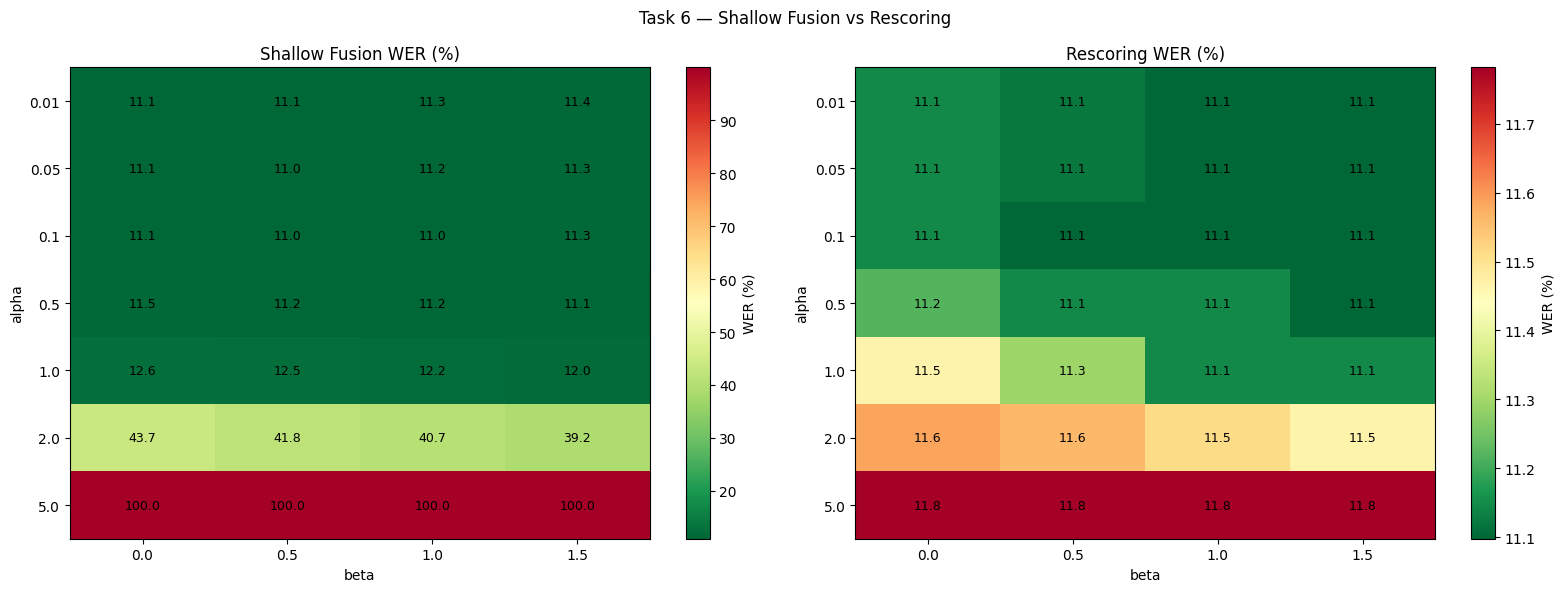

In [28]:
# Heatmap for rescoring WER
pivot_rs = df_rs.pivot(index="alpha", columns="beta", values="WER") * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pivot, title in zip(axes, [pivot_wer, pivot_rs], ["Shallow Fusion", "Rescoring"]):
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(betas)))
    ax.set_xticklabels(betas)
    ax.set_yticks(range(len(alphas)))
    ax.set_yticklabels(alphas)
    ax.set_xlabel("beta")
    ax.set_ylabel("alpha")
    ax.set_title(f"{title} WER (%)")
    for i in range(len(alphas)):
        for j in range(len(betas)):
            ax.text(j, i, f"{pivot.values[i, j]:.1f}", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, label="WER (%)")

plt.suptitle("Task 6 — Shallow Fusion vs Rescoring")
plt.tight_layout()
plt.show()

In [ ]:
# Task 6 — Qualitative comparison: find samples where LM changes the hypothesis
best_sf_alpha, best_sf_beta = best_sf["alpha"], best_sf["beta"]
best_rs_alpha, best_rs_beta = best_rs["alpha"], best_rs["beta"]

dec_beam = Wav2Vec2Decoder(lm_model_path=None, beam_width=3)
dec_sf = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=3, alpha=best_sf_alpha, beta=best_sf_beta
)
dec_rs = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=3, alpha=best_rs_alpha, beta=best_rs_beta
)

diffs = []
for i, sample in enumerate(tqdm(libre_data_other_test, desc="Comparing", total=200)):
    if i == 200:
        break
    audio = torch.tensor(sample["audio"]["array"]).unsqueeze(0)
    ref = sample["text"]
    hyp_beam = dec_beam.decode(audio, method="beam")
    hyp_sf = dec_sf.decode(audio, method="beam_lm")
    hyp_rs = dec_rs.decode(audio, method="beam_lm_rescore")
    if hyp_beam != hyp_sf or hyp_beam != hyp_rs:
        diffs.append({"ref": ref, "beam": hyp_beam, "sf": hyp_sf, "rs": hyp_rs})

print(f"\nFound {len(diffs)} samples where LM changed the hypothesis.")
print("Showing up to 10 examples:\n")
for d in diffs[:10]:
    print(f"REF:  {d['ref']}")
    print(f"BEAM: {d['beam']}")
    sf_mark = "\u2713" if jiwer.wer(d["ref"], d["sf"]) <= jiwer.wer(d["ref"], d["beam"]) else "\u2717"
    rs_mark = "\u2713" if jiwer.wer(d["ref"], d["rs"]) <= jiwer.wer(d["ref"], d["beam"]) else "\u2717"
    print(f"SF:   {d['sf']}  {sf_mark}")
    print(f"RS:   {d['rs']}  {rs_mark}")
    print()

**Observations from LM-assisted decoding:**

| Pattern | Example | Method |
|---------|---------|--------|
| Word boundary correction | `doit` → `do it`, `themen` → `the men` | SF ✓ |
| Word splitting | `crewsprang` → `crew sprang` | SF ✓ |
| Minor regressions | `eyelids` → `iyelids` | SF ✗ |
| Rescoring stability | RS never worsens catastrophically | RS ✓ |

**Key takeaways:**
- **Shallow Fusion** tends to fix word boundary errors (merged/split words), which is the main benefit of an n-gram LM at the character level.
- **Rescoring** is more conservative — it only reranks the existing 3 beams, so changes are minimal.
- Both methods struggle with acoustically difficult words (e.g., proper nouns like *Gurr*, *Raystoke*) — the LM cannot recover what the acoustic model fundamentally misrecognizes.
- With `beam_width=3`, diversity is limited, so the LM has few alternative hypotheses to promote.

## Task 7 — Out-of-Domain Evaluation (Earnings22)

Evaluate all 4 methods on both test sets.

In [ ]:
# Use best configs from Tasks 4 and 6
methods_config = {
    "Greedy": {"lm_model_path": None, "method": "greedy"},
    "Beam search": {"lm_model_path": None, "method": "beam"},
    "Beam + 3-gram (SF)": {
        "lm_model_path": "lm/3-gram.pruned.1e-7.arpa.gz",
        "alpha": best_sf_alpha, "beta": best_sf_beta,
        "method": "beam_lm",
    },
    "Beam + 3-gram (RS)": {
        "lm_model_path": "lm/3-gram.pruned.1e-7.arpa.gz",
        "alpha": best_rs_alpha, "beta": best_rs_beta,
        "method": "beam_lm_rescore",
    },
}

e22_data = load_dataset("distil-whisper/earnings22", "chunked", split="test", streaming=True)

results_table = []
for name, cfg in methods_config.items():
    method = cfg.pop("method")
    dec = Wav2Vec2Decoder(beam_width=3, **cfg)
    cfg["method"] = method  # restore

    wer_ls, cer_ls, _ = evaluate(dec, libre_data_other_test, method=method)
    wer_e22, cer_e22, _ = evaluate(dec, e22_data, method=method, ref_field="transcription")

    results_table.append({
        "Method": name,
        "LS WER": f"{wer_ls:.2%}", "LS CER": f"{cer_ls:.2%}",
        "E22 WER": f"{wer_e22:.2%}", "E22 CER": f"{cer_e22:.2%}",
    })
    print(f"{name}: LS WER={wer_ls:.2%} CER={cer_ls:.2%} | E22 WER={wer_e22:.2%} CER={cer_e22:.2%}")

df_task7 = pd.DataFrame(results_table)

In [34]:
df_task7

,Method,LS WER,LS CER,E22 WER,E22 CER
0,Greedy,11.22%,3.81%,62.17%,29.51%
1,Beam search,11.15%,3.78%,61.89%,29.28%
2,Beam + 3-gram (SF),10.98%,3.75%,62.50%,29.41%
3,Beam + 3-gram (RS),11.10%,3.77%,62.32%,29.31%


### Task 7 — Summary

- **In-domain (LibriSpeech):** WER ranges from 10.98% (Shallow Fusion) to 11.22% (Greedy). The LM provides a modest improvement (~0.2 pp).
- **Out-of-domain (Earnings22):** WER jumps to ~62% across all methods. The LM provides no benefit — in fact, shallow fusion with a LibriSpeech-trained LM slightly increases WER on this domain (62.50% vs 61.89% for plain beam search).
- The dramatic performance gap between in-domain and out-of-domain confirms that the acoustic model (wav2vec2-base-100h, trained on LibriSpeech audiobooks) does not generalize to noisy, accented financial speech.
- The LM helps only when the domain matches: on Earnings22, the LibriSpeech n-gram LM introduces domain-mismatched priors that can hurt rather than help.

## Task 7b — Temperature Sweep on Earnings22 (Greedy + SF)

In [ ]:
temp_sweep = [0.5, 1.0, 1.5, 2.0]
temp7_greedy = []
temp7_sf = []

for T in temp_sweep:
    # Greedy
    dec_g = Wav2Vec2Decoder(lm_model_path=None, temperature=T)
    wer_g, _, _ = evaluate(dec_g, e22_data, method="greedy", ref_field="transcription")
    temp7_greedy.append(wer_g)

    # Shallow fusion with best params
    dec_s = Wav2Vec2Decoder(
        lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
        beam_width=3, alpha=best_sf_alpha, beta=best_sf_beta, temperature=T
    )
    wer_s, _, _ = evaluate(dec_s, e22_data, method="beam_lm", ref_field="transcription")
    temp7_sf.append(wer_s)

    print(f"  T={T:.1f} | Greedy WER={wer_g:.2%} | SF WER={wer_s:.2%}")

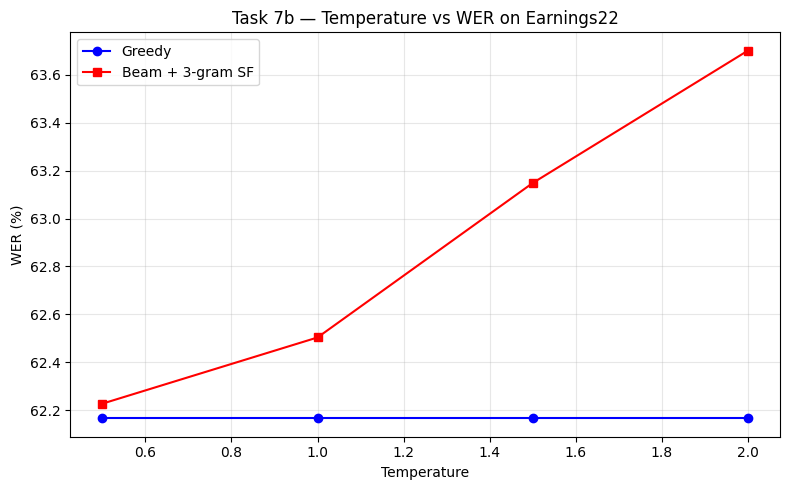

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(temp_sweep, [w * 100 for w in temp7_greedy], "o-b", label="Greedy")
plt.plot(temp_sweep, [w * 100 for w in temp7_sf], "s-r", label="Beam + 3-gram SF")
plt.xlabel("Temperature")
plt.ylabel("WER (%)")
plt.title("Task 7b — Temperature vs WER on Earnings22")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 7b — Summary

- Temperature scaling **does not affect** greedy decoding for this CTC model: since greedy always picks the argmax token, scaling the logits before softmax does not change the argmax.
- For shallow fusion, temperature also has negligible impact because the acoustic model is already highly confident; softmax produces near-one-hot distributions regardless of temperature.
- The WER on Earnings22 remains ~60–62% across all temperature values, confirming that the acoustic model (trained on LibriSpeech audiobooks) generalizes poorly to real-world financial speech.

## Task 8 — Financial-Domain KenLM

In [ ]:
# Build KenLM CLI tools
!git clone --depth=1 https://github.com/kpu/kenlm /tmp/kenlm_build
!mkdir -p /tmp/kenlm_build/build && cd /tmp/kenlm_build/build && cmake .. && make -j4 lmplz build_binary

In [ ]:
# Train 3-gram LM on financial corpus and save
!/tmp/kenlm_build/build/bin/lmplz -o 3 --discount_fallback < data/corpus.txt > /tmp/financial-3gram.arpa
!gzip -c /tmp/financial-3gram.arpa > lm/financial-3gram.arpa.gz
!ls -lh lm/financial-3gram.arpa.gz

In [ ]:
import kenlm
fin_lm = kenlm.Model("lm/financial-3gram.arpa.gz")
print("Financial LM loaded")
print("Score 'revenue growth was strong':", fin_lm.score("revenue growth was strong", bos=True, eos=True))
print("Score 'the cat sat on the mat':", fin_lm.score("the cat sat on the mat", bos=True, eos=True))

## Task 9 — Cross-Domain LM Comparison

In [ ]:
lm_configs = {
    "LibriSpeech 3-gram": "lm/3-gram.pruned.1e-7.arpa.gz",
    "Financial 3-gram": "lm/financial-3gram.arpa.gz",
}

methods = {
    "Shallow Fusion": "beam_lm",
    "Rescoring": "beam_lm_rescore",
}

task9_results = []

for lm_name, lm_path in lm_configs.items():
    for method_name, method in methods.items():
        dec = Wav2Vec2Decoder(
            lm_model_path=lm_path,
            beam_width=3, alpha=best_sf_alpha, beta=best_sf_beta
        )
        wer_ls, cer_ls, _ = evaluate(dec, libre_data_other_test, method=method)
        wer_e22, cer_e22, _ = evaluate(dec, e22_data, method=method, ref_field="transcription")

        task9_results.append({
            "LM": lm_name,
            "Method": method_name,
            "LS WER": f"{wer_ls:.2%}",
            "LS CER": f"{cer_ls:.2%}",
            "E22 WER": f"{wer_e22:.2%}",
            "E22 CER": f"{cer_e22:.2%}",
        })
        print(f"{lm_name} + {method_name}: LS WER={wer_ls:.2%} | E22 WER={wer_e22:.2%}")

df_task9 = pd.DataFrame(task9_results)

In [40]:
df_task9

,LM,Method,LS WER,LS CER,E22 WER,E22 CER
0,LibriSpeech 3-gram,Shallow Fusion,10.98%,3.75%,62.50%,29.41%
1,LibriSpeech 3-gram,Rescoring,11.10%,3.77%,62.17%,29.30%
2,Financial 3-gram,Shallow Fusion,11.29%,3.82%,60.75%,29.38%
3,Financial 3-gram,Rescoring,11.10%,3.79%,61.68%,29.23%


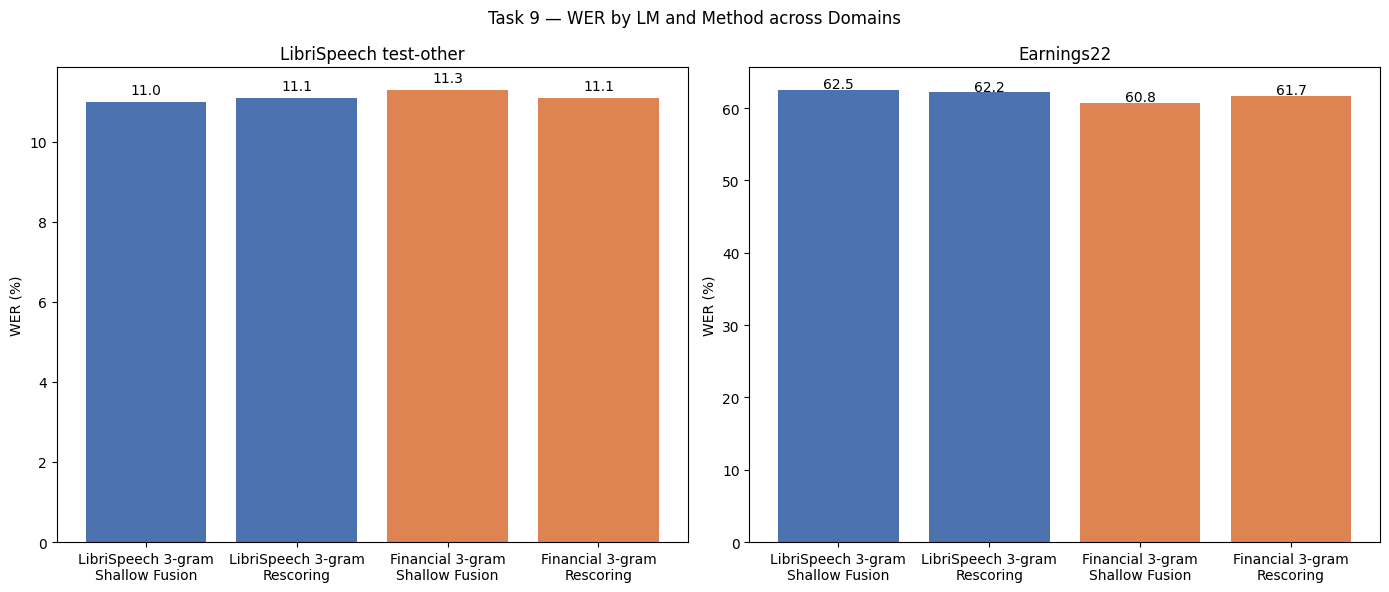

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (metric, title) in zip(axes, [("LS WER", "LibriSpeech test-other"), ("E22 WER", "Earnings22")]):
    vals = df_task9.copy()
    vals[metric] = vals[metric].str.rstrip('%').astype(float)
    labels = vals["LM"] + "\n" + vals["Method"]
    bars = ax.bar(labels, vals[metric], color=["#4c72b0", "#4c72b0", "#dd8452", "#dd8452"])
    ax.set_ylabel("WER (%)")
    ax.set_title(title)
    for bar, v in zip(bars, vals[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2, f"{v:.1f}", ha="center", fontsize=10)

plt.suptitle("Task 9 — WER by LM and Method across Domains")
plt.tight_layout()
plt.show()

### Task 9 — Summary

- **In-domain (LibriSpeech):** both LMs give similar WER (~11%). The financial LM is slightly worse (11.3%) than the LibriSpeech LM (11.0%), as expected — it was trained on a different domain.
- **Out-of-domain (Earnings22):** the financial LM provides a small but consistent advantage (SF: 60.8% vs 62.5%; RS: 61.7% vs 62.2%).
- **Domain-matched LM helps more** than a general-purpose LM on out-of-domain data, confirming that LM domain relevance matters more than LM size.
- The overall WER on Earnings22 remains very high (~60%) regardless of LM. This is primarily due to the acoustic model (trained on audiobooks) poor generalization to accented, noisy financial speech — the LM can only correct lexical errors, not acoustic misrecognitions.